# Laboratorio 4 — Cuaderno 8: variable respuesta y variables predictoras

**Ejercicios 2 y 3 de la Parte 2.**

El cuaderno 7 dejó en `data/derived/dataset_ml.parquet` una tabla con una fila por
píxel de agua válida: 3,759,121 observaciones repartidas en 22 escenas. Aquí se
convierte la clorofila continua en la etiqueta binaria que van a predecir los modelos,
se justifica el punto de corte con bibliografía, y se decide qué variables pueden y
qué variables no pueden entrar como predictoras.

La segunda mitad es la parte delicada del laboratorio. El enunciado advierte que
*"una variable utilizada directa o indirectamente para construir la variable respuesta
no deberá incluirse posteriormente como variable predictora"*, y en este problema esa
advertencia no es una formalidad: la respuesta se deriva de dos bandas concretas, y si
esas dos bandas entran al modelo el problema deja de existir.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config, ml
from src import indices as ix

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
print(f"{len(datos):,} observaciones, {datos.shape[1]} columnas")

COLOR = {"Atitlan": "#1f6f8b", "Amatitlan": "#c1272d"}

3,759,121 observaciones, 22 columnas


## 2.1 Construcción de la variable respuesta binaria

Se define `alta_cianobacteria` = 1 cuando la clorofila-a estimada supera 10 µg/L, y 0
en caso contrario. El umbral no se elige aquí por conveniencia estadística: viene de la
Parte I, donde ya se usó para medir la extensión de las floraciones, y está definido en
`src/indices.py` como `UMBRAL_ALTO_CHL`. El módulo `src/ml.py` lo importa de ahí en vez
de repetir el número, para que las dos partes del laboratorio no puedan desincronizarse.

In [2]:
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)

n = len(datos)
n_pos = int(datos[ml.RESPUESTA].sum())
n_neg = n - n_pos

print(f"Umbral: {ml.UMBRAL_CHL} µg/L de clorofila-a")
print(f"Total observaciones:      {n:,}")
print(f"  Clase 0 (baja/ausencia): {n_neg:,}  ({100*n_neg/n:.2f} %)")
print(f"  Clase 1 (alta presencia):{n_pos:,}  ({100*n_pos/n:.2f} %)")
print(f"  Razón de desbalance:     {n_neg/n_pos:.0f} negativos por positivo")

Umbral: 10.0 µg/L de clorofila-a
Total observaciones:      3,759,121
  Clase 0 (baja/ausencia): 3,714,772  (98.82 %)
  Clase 1 (alta presencia):44,349  (1.18 %)
  Razón de desbalance:     84 negativos por positivo


## 2.2 Justificación del punto de corte

### Qué se considera alto desde el punto de vista sanitario

La referencia operativa son las guías de la Organización Mundial de la Salud para aguas
recreativas. La OMS no fija un único valor de corte sino un esquema escalonado de
vigilancia, en el que la clorofila-a se usa como indicador indirecto de la biomasa de
cianobacteria cuando estas dominan el fitoplancton:

| Nivel | Clorofila-a | Densidad celular aproximada | Qué implica |
|---|---|---|---|
| Vigilancia | **10 µg/L** | ~20,000 células/mL | Se inicia el monitoreo; riesgo bajo pero no nulo de efectos irritativos |
| Alerta | **50 µg/L** | ~100,000 células/mL | Probabilidad alta de síntomas; se recomienda restringir el contacto |
| Emergencia | Nata visible | — | Riesgo agudo por toxinas; cierre del uso recreativo |

Se toma **10 µg/L**, el nivel de vigilancia, por tres razones.

**Primera, es el umbral de decisión relevante para un gestor.** El propósito declarado
del laboratorio es apoyar el monitoreo. La pregunta útil no es "¿hay una emergencia?"
sino "¿en qué zona hay que ir a muestrear?". Ese es exactamente el nivel de vigilancia.

**Segunda, coincide con la frontera de eutrofia.** La clasificación trófica de la OCDE
sitúa la frontera entre agua mesotrófica y eutrófica alrededor de 7–8 µg/L de
clorofila-a media. Un píxel por encima de 10 µg/L está, por cualquiera de los dos
criterios, fuera del rango de un cuerpo de agua sano.

**Tercera, y decisiva en estos datos: es el único umbral que discrimina.** Con 50 µg/L
la superficie afectada resultaba de 0.00 % en Atitlán y 0.15 % en Amatitlán, y todo el
análisis de extensión de la Parte I se convertía en una tabla de ceros. Con 10 µg/L la
diferencia entre los dos lagos aparece con claridad. Un umbral que no separa nada no
sirve como variable respuesta.

### Limitación honesta de este criterio

La clorofila-a mide fitoplancton total, no cianobacteria. Las guías de la OMS aplican
el equivalente en células **cuando las cianobacterias dominan** la comunidad. Aquí no
hay conteo celular que confirme esa dominancia: se está asumiendo, apoyándose en que el
script utilizado es específico para cianobacteria y en que la Parte I encontró
correlación alta entre la clorofila y el índice de material flotante en Amatitlán
(r = 0.844), que es la firma de una nata de cianobacteria. En Atitlán esa correlación
baja a 0.304, así que allí la asunción es más débil. Esto se retoma en el cuaderno de
conclusiones.

### Bibliografía consultada

- Organización Mundial de la Salud (2003). *Guidelines for Safe Recreational Water
  Environments. Volume 1: Coastal and Fresh Waters*. Capítulo 8, "Algae and
  cyanobacteria in fresh water". Es la fuente del esquema escalonado de 10 y 50 µg/L.
- Organización Mundial de la Salud (2021). *Guidelines on Recreational Water Quality.
  Volume 1: Coastal and Fresh Waters*. Edición revisada, que mantiene el enfoque de
  niveles de vigilancia y alerta.
- Organización Mundial de la Salud (2020). *Cyanobacterial Toxins: Microcystins*.
  Background document for development of WHO Guidelines for Drinking-water Quality and
  Guidelines for Safe Recreational Water Environments.
- OCDE (1982). *Eutrophication of Waters: Monitoring, Assessment and Control*. Fuente de
  las fronteras de estado trófico usadas en la Parte I.
- Kravitz, J. y Matthews, M. (2020). *CyanoLakes Chlorophyll-a*, script personalizado
  para Sentinel-2 L1C, repositorio de custom scripts de Sentinel Hub. Es el índice del
  que sale la clorofila que aquí se umbrala.

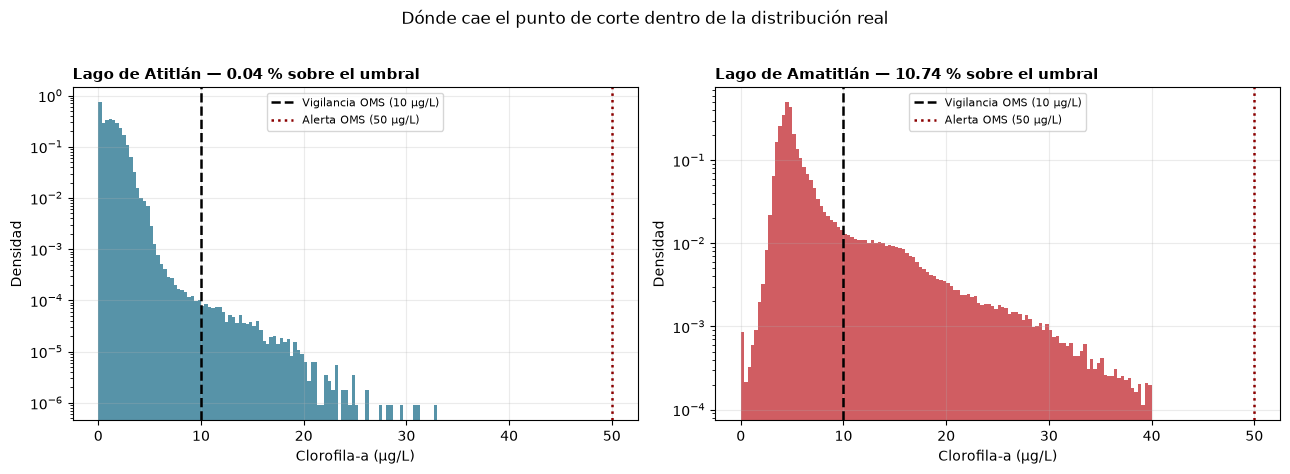

In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.6))

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    sub = datos.loc[datos["lago"] == lago, "chl"]
    eje.hist(sub, bins=120, range=(0, 40), color=COLOR[lago], alpha=0.75, density=True)
    eje.axvline(ml.UMBRAL_CHL, color="black", linestyle="--", linewidth=1.8,
                label=f"Vigilancia OMS ({ml.UMBRAL_CHL:.0f} µg/L)")
    eje.axvline(ix.UMBRAL_ALERTA_CHL, color="#8b0000", linestyle=":", linewidth=1.8,
                label=f"Alerta OMS ({ix.UMBRAL_ALERTA_CHL:.0f} µg/L)")
    pct = 100 * (sub > ml.UMBRAL_CHL).mean()
    eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {pct:.2f} % sobre el umbral",
                  loc="left", fontsize=11, fontweight="bold")
    eje.set_xlabel("Clorofila-a (µg/L)")
    eje.set_ylabel("Densidad")
    eje.set_yscale("log")
    eje.legend(fontsize=8)
    eje.grid(alpha=0.25)

fig.suptitle("Dónde cae el punto de corte dentro de la distribución real", y=1.02)
fig.tight_layout()
plt.show()

El eje vertical está en escala logarítmica: sin ella la cola por encima del umbral no se
ve, que es justamente el problema del que trata el inciso 2.4.

Los dos lagos no son el mismo problema. Atitlán tiene toda su masa por debajo de
5 µg/L y apenas una cola raquítica cruzando el umbral. Amatitlán tiene el grueso de su
distribución entre 4 y 8 µg/L, pegado al umbral por debajo, con una cola gruesa que lo
cruza. Eso significa que en Amatitlán una variación pequeña de la clorofila mueve muchos
píxeles de clase, y en Atitlán no mueve ninguno.

## 2.3 Distribución de la variable respuesta

In [4]:
print("GLOBAL")
print(f"  0: {n_neg:>10,}  ({100*n_neg/n:6.2f} %)")
print(f"  1: {n_pos:>10,}  ({100*n_pos/n:6.2f} %)\n")

print("POR LAGO")
por_lago = datos.groupby("lago")[ml.RESPUESTA].agg(["size", "sum", "mean"])
por_lago.columns = ["observaciones", "positivos", "proporcion"]
por_lago["porcentaje"] = (100 * por_lago["proporcion"]).round(4)
print(por_lago[["observaciones", "positivos", "porcentaje"]].to_string())

print("\nPOR LAGO Y FECHA")
por_fecha = datos.groupby(["lago", "fecha"])[ml.RESPUESTA].agg(["size", "sum", "mean"])
por_fecha.columns = ["observaciones", "positivos", "proporcion"]
por_fecha["pct_positivos"] = (100 * por_fecha["proporcion"]).round(3)
print(por_fecha[["observaciones", "positivos", "pct_positivos"]].to_string())

GLOBAL
  0:  3,714,772  ( 98.82 %)
  1:     44,349  (  1.18 %)

POR LAGO
           observaciones  positivos  porcentaje
lago                                           
Amatitlan         400756      43025     10.7360
Atitlan          3358365       1324      0.0394

POR LAGO Y FECHA
                      observaciones  positivos  pct_positivos
lago      fecha                                              
Amatitlan 2025-01-28          36652         22          0.060
          2025-04-15          36295        251          0.692
          2025-04-28          36289       2689          7.410
          2025-11-24          36475        733          2.010
          2026-01-08          36772       2562          6.967
          2026-02-02          36231          5          0.014
          2026-02-07          36667         18          0.049
          2026-03-29          36703       2843          7.746
          2026-04-13          36895       1800          4.879
          2026-04-28          35035

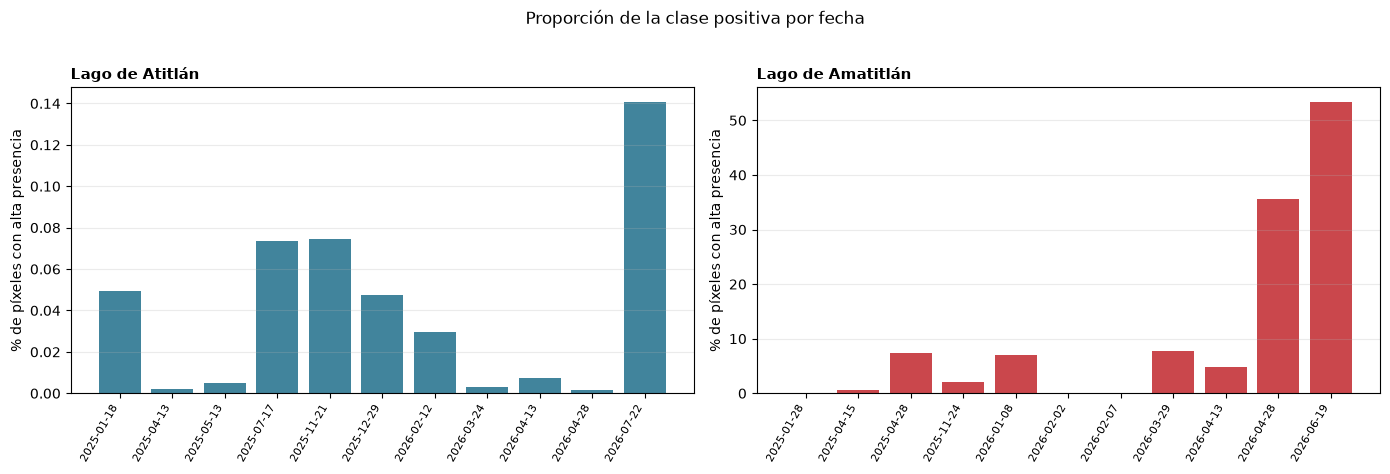

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=False)

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    sub = por_fecha.loc[lago]
    eje.bar(range(len(sub)), 100 * sub["proporcion"], color=COLOR[lago], alpha=0.85)
    eje.set_xticks(range(len(sub)))
    eje.set_xticklabels([f.strftime("%Y-%m-%d") for f in sub.index], rotation=60,
                        ha="right", fontsize=8)
    eje.set_ylabel("% de píxeles con alta presencia")
    eje.set_title(config.NOMBRE_LARGO[lago], loc="left", fontsize=11, fontweight="bold")
    eje.grid(alpha=0.25, axis="y")

fig.suptitle("Proporción de la clase positiva por fecha", y=1.02)
fig.tight_layout()
plt.show()

La clase positiva no está repartida de forma pareja en el tiempo ni en el espacio, y esa
es una observación con consecuencias para el resto del laboratorio.

En **Atitlán** ninguna fecha llega al 0.15 %. El máximo es el 22 de julio de 2026 con
0.141 %, y el mínimo lo comparten las dos escenas de abril —13 de abril de 2025 y 28 de
abril de 2026— con 0.002 % cada una. En términos absolutos son 1,324 píxeles positivos
repartidos en 3.36 millones.

En **Amatitlán** hay una tendencia clara y creciente: de 0.06 % en enero de 2025 a
53.4 % en junio de 2026. Las tres últimas fechas concentran la mayoría de los positivos
del lago. Esto importa para la validación temporal del cuaderno 10: si una partición deja
justo esas fechas fuera del entrenamiento, el modelo se queda casi sin ejemplos positivos.

## 2.4 Desbalance entre clases y sus consecuencias

In [6]:
print("GRADO DE DESBALANCE\n")
print(f"{'ámbito':<14}{'negativos':>12}{'positivos':>11}{'razón 0:1':>12}")
print("-" * 49)
print(f"{'Global':<14}{n_neg:>12,}{n_pos:>11,}{n_neg/n_pos:>11.0f}:1")
for lago, fila in por_lago.iterrows():
    neg = int(fila["observaciones"] - fila["positivos"])
    pos = int(fila["positivos"])
    print(f"{lago:<14}{neg:>12,}{pos:>11,}{neg/pos:>11.0f}:1")

print("\nReferencia: un clasificador trivial que responda siempre 0 obtendría")
print(f"  accuracy global    = {100*n_neg/n:.2f} %")
for lago, fila in por_lago.iterrows():
    print(f"  accuracy {lago:<10} = {100*(1-fila['proporcion']):.2f} %")
print("...y un recall de 0 %. No detectaría ni una sola floración.")

GRADO DE DESBALANCE

ámbito           negativos  positivos   razón 0:1
-------------------------------------------------
Global           3,714,772     44,349         84:1
Amatitlan          357,731     43,025          8:1
Atitlan          3,357,041      1,324       2536:1

Referencia: un clasificador trivial que responda siempre 0 obtendría
  accuracy global    = 98.82 %
  accuracy Amatitlan  = 89.26 %
  accuracy Atitlan    = 99.96 %
...y un recall de 0 %. No detectaría ni una sola floración.


Sí existe desbalance, y es extremo: **84 negativos por cada positivo** a nivel global. Al
separar por lago la situación es de dos órdenes de magnitud distintos, 2,536:1 en Atitlán
contra 8:1 en Amatitlán.

Las consecuencias sobre el entrenamiento y la evaluación son cuatro, y condicionan
decisiones concretas más adelante:

**1. El accuracy deja de ser informativo.** Un modelo que responda siempre "no hay
floración" acierta el 98.82 % de las veces a nivel global y el 99.96 % en Atitlán. Es un
número excelente para un modelo inútil. Por eso el accuracy se reporta —el enunciado lo
pide— pero no se usa para comparar ni para seleccionar.

**2. La función de pérdida se desentiende de la clase rara.** Con 84:1, un modelo que
mejora un poco en los negativos gana más que uno que acierta todos los positivos. La
respuesta es entrenar con la clase positiva completa y una muestra de negativos, o pesar
las clases. En el cuaderno 9 se hace lo primero.

**3. La curva ROC se ve mejor de lo que es.** La tasa de falsos positivos divide entre
3.7 millones de negativos, así que se mantiene cerca de cero aunque el modelo produzca
miles de falsas alarmas. Por eso a las cinco métricas del enunciado se le agrega el área
bajo la curva precision-recall, que es la que la literatura usa con clases raras.

**4. Atitlán no puede sostener un entrenamiento por sí solo.** Con 1,324 positivos entre
3.36 millones, cualquier partición aleatoria deja folds con un puñado de casos positivos.
Esto es exactamente lo que va a limitar el Experimento A del ejercicio 7, y conviene
tenerlo anotado desde ahora en vez de descubrirlo como una sorpresa.

Lo que **no** se hace es excluir a Atitlán del modelado. Es tentador, porque su
desbalance es feísimo, pero dejaría sin sentido el ejercicio 7 —que pide entrenar en un
lago y evaluar en el otro— y el inciso 9.3, que pide un mapa predictivo por lago.

## 2.5 Variables que no pueden usarse como predictoras

Aquí está el punto sobre el que el enunciado advierte de forma explícita. No es una
precaución teórica: en estos datos la variable respuesta es una función cerrada de dos
columnas de la tabla, y se puede demostrar.

La cadena de construcción es esta:

$$\text{NDCI} = \frac{B05 - B04}{B05 + B04}
\qquad
\text{chl} = 826.57\,\text{NDCI}^3 - 176.43\,\text{NDCI}^2 + 19\,\text{NDCI} + 4.071$$

$$\text{alta\_cianobacteria} = \mathbb{1}[\text{chl} > 10]$$

Como el polinomio es monótono creciente en el rango de interés, umbralar la clorofila en
10 µg/L equivale a umbralar el NDCI en la raíz real de la ecuación
$826.57n^3 - 176.43n^2 + 19n + 4.071 = 10$. Esa raíz es $n^* = 0.2413494$. Y despejando
en bandas:

$$\frac{B05 - B04}{B05 + B04} > 0.2413494
\quad\Longleftrightarrow\quad
B05 > 1.636\,B04$$

La etiqueta es **una desigualdad lineal entre dos columnas del conjunto de datos**. Se
verifica sobre las 3.76 millones de filas:

In [7]:
regla_ndci = (datos["ndci"] > ml.UMBRAL_NDCI).astype("int8")
regla_bandas = (datos["B05"] > 1.6362 * datos["B04"]).astype("int8")

print(f"Umbral en NDCI equivalente a {ml.UMBRAL_CHL} µg/L: {ml.UMBRAL_NDCI:.7f}\n")
print(f"'ndci > {ml.UMBRAL_NDCI:.6f}' reproduce la etiqueta en "
      f"{100*(regla_ndci == datos[ml.RESPUESTA]).mean():.4f} % de las filas")
print(f"'B05 > 1.6362 * B04'          reproduce la etiqueta en "
      f"{100*(regla_bandas == datos[ml.RESPUESTA]).mean():.4f} % de las filas")

Umbral en NDCI equivalente a 10.0 µg/L: 0.2413494

'ndci > 0.241349' reproduce la etiqueta en 100.0000 % de las filas
'B05 > 1.6362 * B04'          reproduce la etiqueta en 99.9999 % de las filas


Coincidencia perfecta en el primer caso y prácticamente perfecta en el segundo —la
diferencia sale del redondeo del coeficiente a cuatro decimales—. Un clasificador que
reciba `B04` y `B05` no está prediciendo la presencia de cianobacteria: está recalculando
la definición de la etiqueta. Obtendría un ROC-AUC de 1.0 y no habría aprendido nada.

De ahí sale la lista de exclusiones, que vive en `src/ml.py` junto con su motivo para que
ningún cuaderno la reconstruya a mano:

In [8]:
print(f"{'variable':<10}  motivo")
print("-" * 96)
for var, motivo in ml.EXCLUIDAS.items():
    envuelto = motivo
    print(f"{var:<10}  {envuelto[:84]}")
    resto = envuelto[84:]
    while resto:
        print(f"{'':<10}  {resto[:84].lstrip()}")
        resto = resto[84:]

variable    motivo
------------------------------------------------------------------------------------------------
chl         Es la variable con la que se construye la respuesta.
ndci        chl es un polinomio del NDCI: la respuesta es NDCI > 0.2413.
B04         Denominador y numerador del NDCI. Con B05 reconstruye la etiqueta.
B05         Denominador y numerador del NDCI. Con B04 reconstruye la etiqueta.
ndvi        Se calcula con B04, una de las dos bandas que arman la respuesta.
fai         Se calcula con B04, una de las dos bandas que arman la respuesta.
B10         Banda de cirrus. Se uso para filtrar nube, asi que por construccion vale menos de 0.
            01 en toda observacion que sobrevivio: no aporta.
lago        No es fuga, pero se deja fuera a proposito: con 10.7% de positivos en Amatitlan cont
            ra 0.04% en Atitlan, el modelo aprenderia el nombre del lago en vez de la senal espe
            ctral y el ejercicio 7 perderia sentido.
fecha       Se reserva com

Tres de esas exclusiones merecen comentario porque no son evidentes.

**`ndvi` y `fai` salen aunque no aparezcan en la fórmula de la clorofila.** El NDVI se
calcula como $(B08-B04)/(B08+B04)$ y el FAI usa $B04$ en su línea base. Ambos contienen
$B04$, que es una de las dos bandas que arman la respuesta. El enunciado dice "directa o
**indirectamente**", y este es el caso indirecto. Es una pérdida real —el enunciado pide
en el inciso 1.2 que el NDVI esté en el conjunto de datos— pero estar en el conjunto de
datos y ser predictora son cosas distintas.

**`B10` sale por un motivo diferente, no por fuga.** Es la banda de cirrus y se usó para
filtrar nube, así que por construcción vale menos de 0.01 en toda observación que
sobrevivió al filtro. Es prácticamente una constante y no aporta información.

**`lago` sale a propósito, y tampoco es fuga.** Con 10.7 % de positivos en Amatitlán
contra 0.04 % en Atitlán, un modelo con acceso al nombre del lago aprendería "Amatitlán
⇒ probablemente sí" y se ahorraría mirar el espectro. Eso destruiría el ejercicio 7, que
pide precisamente medir si lo aprendido en un lago se transfiere al otro.

## 3.1 Conjunto de variables predictoras

Lo que queda después de quitar todo lo anterior son 16 variables: siete bandas
espectrales, seis índices construidos únicamente con bandas permitidas y tres
características espaciales.

In [9]:
datos = ml.caracteristicas(datos)

print(f"{len(ml.PREDICTORAS)} variables predictoras\n")
print(f"  Bandas ({len(ml.BANDAS)}):      {', '.join(ml.BANDAS)}")
print(f"  Derivadas ({len(ml.DERIVADAS)}):   {', '.join(ml.DERIVADAS)}")
print(f"  Espaciales ({len(ml.ESPACIALES)}):  {', '.join(ml.ESPACIALES)}")

solapamiento = set(ml.PREDICTORAS) & set(ml.EXCLUIDAS)
print(f"\nComprobación — predictoras que además están excluidas: {solapamiento or 'ninguna'}")
print(f"Valores faltantes en las predictoras: {int(datos[ml.PREDICTORAS].isna().sum().sum())}")

16 variables predictoras



  Bandas (7):      B02, B03, B07, B08, B8A, B11, B12
  Derivadas (6):   ndwi, mndwi, ndmi, razon_azul_verde, nd_borde_verde, brillo_visible
  Espaciales (3):  x, y, dist_orilla_m

Comprobación — predictoras que además están excluidas: ninguna


Valores faltantes en las predictoras: 0


## 3.2 Qué representa cada variable y por qué podría ayudar

In [10]:
filas = []
for var in ml.PREDICTORAS:
    tipo, texto = ml.DESCRIPCION[var]
    filas.append({"variable": var, "tipo": tipo, "qué representa y por qué podría ayudar": texto})

tabla_pred = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 200, "display.width", 210):
    print(tabla_pred.to_string(index=False))

        variable     tipo                                                                                                                                 qué representa y por qué podría ayudar
             B02    banda                                                     Azul, 490 nm. La clorofila-a absorbe con fuerza en el azul, asi que el agua con mas fitoplancton se oscurece aqui.
             B03    banda                                                                   Verde, 560 nm. Maximo de reflectancia del fitoplancton: es la banda donde una floracion se ve verde.
             B07    banda Borde rojo, 783 nm. Reflectancia alta sobre agua cargada de algas y casi nula sobre agua limpia. Es la senal de clorofila mas fuerte que queda tras excluir B04 y B05.
             B08    banda                                Infrarrojo cercano, 842 nm. El agua limpia lo absorbe casi por completo; lo que refleje delata material en suspension o algas flotando.
             B8A    banda          

La pieza importante de este conjunto es **B07**. Es la banda de borde rojo a 783 nm y es
lo más parecido que queda a la señal que se perdió al excluir B05 (705 nm): sobre agua
cargada de algas la reflectancia en el borde rojo sube, y sobre agua limpia es casi nula.
La diferencia con B05 es que B07 no interviene en ninguna fórmula de la variable
respuesta, así que la información que aporta se obtuvo de forma independiente.

Las dos bandas de onda corta, **B11 y B12**, cumplen un papel menos obvio pero necesario
en este problema concreto. El agua las absorbe siempre, sea limpia o cargada de algas, de
modo que lo que reflejen tiene que venir de material mineral en suspensión. Sirven de
control: permiten al modelo separar turbidez por sedimento de turbidez por biomasa. Esto
importa sobre todo en Amatitlán, donde la Parte I encontró que el NDWI **no** predice la
clorofila (r = −0.348, p = 0.29) precisamente porque el sedimento del río Villalobos
compite por la señal óptica, mientras que en Atitlán sí la predice (r = −0.955).

## 3.3 Ingeniería de características

Las seis variables derivadas no son combinaciones arbitrarias. Cada una responde a una
pregunta física distinta y todas se construyen exclusivamente con bandas permitidas.

| Variable | Fórmula | Qué añade sobre las bandas crudas |
|---|---|---|
| `ndwi` | $(B03-B08)/(B03+B08)$ | Normaliza el contraste verde–infrarrojo, así que no depende del brillo absoluto de la escena ni del ángulo solar |
| `mndwi` | $(B03-B11)/(B03+B11)$ | Igual que el anterior pero contra el SWIR, más estable cerca de la orilla y frente a vegetación emergente |
| `ndmi` | $(B08-B11)/(B08+B11)$ | Sube cuando hay biomasa flotando; separa material en superficie de material disuelto |
| `razon_azul_verde` | $B02/B03$ | Es la forma clásica de estimar clorofila-a en color del océano: el pigmento absorbe azul y refleja verde, así que la razón cae cuando hay más fitoplancton |
| `nd_borde_verde` | $(B07-B03)/(B07+B03)$ | Análogo estructural del NDCI, armado con dos bandas que no intervienen en la respuesta |
| `brillo_visible` | $B02+B03$ | Nivel general de turbidez, sin normalizar; da la escala que los índices normalizados descartan |

La justificación de fondo para normalizar es la misma en los cuatro índices: una razón
entre bandas cancela los factores multiplicativos que afectan a toda la escena por igual
—iluminación, geometría de observación, transmitancia atmosférica— y deja la forma del
espectro, que es donde está la información sobre lo que hay en el agua.

`nd_borde_verde` merece una advertencia. Es deliberadamente análogo al NDCI: mismo tipo
de contraste, entre una banda de borde rojo y una banda de referencia más corta. La
diferencia es que usa B07 y B03 en vez de B05 y B04, y ninguna de las dos interviene en
la construcción de la respuesta. No es fuga, pero sí explica por qué el desempeño va a
salir alto: se está midiendo el mismo fenómeno físico con otro par de bandas.

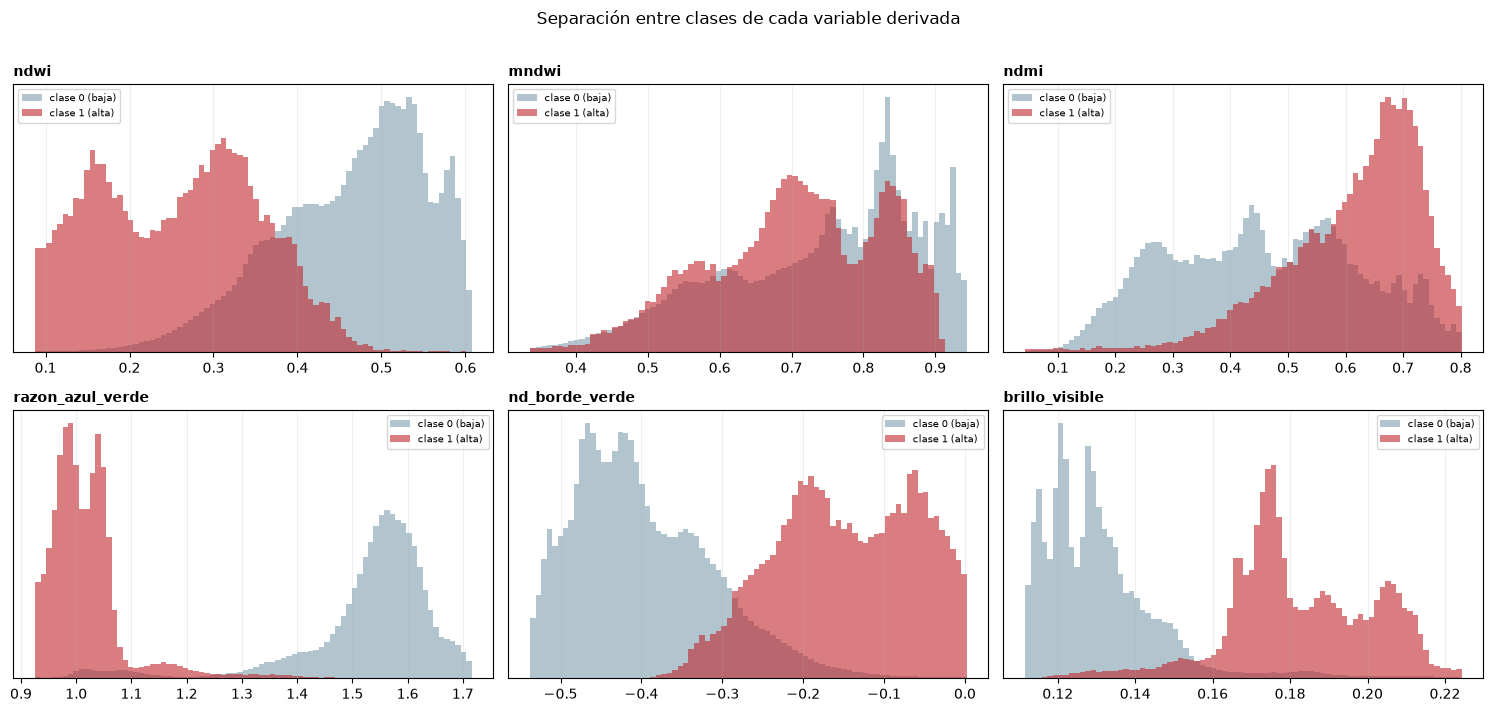

In [11]:
fig, ejes = plt.subplots(2, 3, figsize=(15, 7))

for eje, var in zip(ejes.ravel(), ml.DERIVADAS):
    for etiqueta, color, nombre in [(0, "#7f9fb0", "baja"), (1, "#c1272d", "alta")]:
        sub = datos.loc[datos[ml.RESPUESTA] == etiqueta, var]
        lo, hi = np.nanpercentile(datos[var], [0.5, 99.5])
        eje.hist(sub, bins=80, range=(lo, hi), density=True, alpha=0.6,
                 color=color, label=f"clase {etiqueta} ({nombre})")
    eje.set_title(var, loc="left", fontsize=10, fontweight="bold")
    eje.set_yticks([])
    eje.grid(alpha=0.2)
    eje.legend(fontsize=7)

fig.suptitle("Separación entre clases de cada variable derivada", y=1.01)
fig.tight_layout()
plt.show()

In [12]:
correlacion = datos[ml.PREDICTORAS + [ml.RESPUESTA]].corr()[ml.RESPUESTA].drop(ml.RESPUESTA)
orden = correlacion.abs().sort_values(ascending=False)

print("Correlación de Pearson de cada predictora con la etiqueta\n")
for var in orden.index:
    barra = "#" * int(round(40 * abs(correlacion[var])))
    print(f"  {var:<18}{correlacion[var]:+.3f}  {barra}")

Correlación de Pearson de cada predictora con la etiqueta

  B07               +0.506  ####################
  B08               +0.456  ##################
  B8A               +0.413  #################
  razon_azul_verde  -0.376  ###############
  nd_borde_verde    +0.367  ###############
  B03               +0.350  ##############
  ndwi              -0.313  #############
  x                 +0.295  ############
  brillo_visible    +0.290  ############
  y                 -0.281  ###########
  B02               +0.171  #######
  B11               +0.110  ####
  dist_orilla_m     -0.107  ####
  ndmi              +0.096  ####
  B12               +0.066  ###
  mndwi             -0.030  #


Las cuatro primeras son bandas del borde rojo y del infrarrojo cercano —B07 con +0.506,
B08 con +0.456, B8A con +0.413— seguidas de `razon_azul_verde` con −0.376 y
`nd_borde_verde` con +0.367. Es el orden que cabía esperar por lo argumentado arriba: lo
que más separa las clases es el realce de reflectancia en el borde rojo, que es la firma
óptica de la clorofila, y la caída de la razón azul/verde, que es el mismo fenómeno visto
desde el otro extremo del espectro.

`dist_orilla_m` aparece con −0.107, una correlación débil y en la dirección esperada: los
píxeles positivos tienden a estar más cerca de la orilla. Débil no significa inútil —una
correlación lineal no capta que el efecto sea local o no monótono— y el cuaderno 12
volverá sobre ella con SHAP para ver si los modelos le encuentran más uso del que sugiere
este número.

Ninguna correlación individual llega a ser tan alta como para levantar sospecha de fuga
—la que sí lo era, el NDCI, correlacionaba de forma perfecta por construcción—. Que los
modelos del cuaderno 9 vayan a superar esas correlaciones individuales es lo esperable:
combinan las 16 variables y capturan interacciones que una correlación lineal por
separado no ve.

---

**Siguiente:** `09_Modelos_ML.ipynb` — construcción y evaluación de los tres modelos
(ejercicios 4 y 5).